# Caesar cipher
![Caesar cipher](Images/caesar_cipher.png)

> ￼In cryptography, a Caesar cipher, also known as Caesar's cipher, the shift cipher, Caesar's code or Caesar shift, is one of the simplest and most widely known encryption techniques. It is a type of substitution cipher in which each letter in the plaintext is replaced by a letter some fixed number of positions down the alphabet. For example, with a left shift of 3, D would be replaced by A, E would become B, and so on. The method is named after Julius Caesar, who used it in his private correspondence.

From Wikipedia, the free encyclopedia

### Exercises TODO:

1. Implement `encode` and `decode` functions for a right shift Caesar cipher.
1. Test Caesar cipher functionality by encoding and decoding a simple message
1. Decode the secret message below

**BKFTAZDGXQE**


### Implement encode and decode functions for a right shift Caesar cipher.

In [32]:
ascii_uppercase = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'

def encode(string, shift):
    """encode a string with Caesar chiper given a shift cipher. Returns encoded string"""
    res = list(string)
    for i in range(len(res)):
        res[i] = ascii_uppercase[(ascii_uppercase.index(res[i]) + shift) % 26]
    
    return ''.join(res)
   
def decode(string, shift):
    """decode a string with Caesar cipher given a shift cipher. Returns decoded string"""
    res = list(string)
    for i in range(len(res)):
        res[i] = ascii_uppercase[(ascii_uppercase.index(res[i]) - shift) % 26]
    
    return ''.join(res)

### Test Caesar cipher encode/decode functions

In [33]:
shift = 12

plain = "messageinabottle"

plain = plain.upper()

cipher = encode(plain, shift)
decoded = decode(cipher, shift)

print("message =", plain)
print("cipher  =", cipher)
print("decoded =", decoded)

message = MESSAGEINABOTTLE
cipher  = YQEEMSQUZMNAFFXQ
decoded = MESSAGEINABOTTLE


# Breaking the cipher

> Since there are only a limited number of possible shifts (26 in English), they can each be tested in turn in a brute force attack.

> Another brute force approach is to match up the frequency distribution of the letters. By graphing the frequencies of letters in the ciphertext, and by knowing the expected distribution of those letters in the original language of the plaintext, a human can easily spot the value of the shift by looking at the displacement of particular features of the graph. This is known as frequency analysis. For example, in the English language the plaintext frequencies of the letters E, T, (usually most frequent), and Q, Z (typically least frequent) are particularly distinctive. Computers can also do this by measuring how well the actual frequency distribution matches up with the expected distribution; for example, the chi-squared statistic can be used.

## Exercise: Breaking the cipher TODO
* Decode a secret ciphered text. The secret is written in file 'the_secret.txt'.
* Compare frequencies of letters in the secret text with the standard frequencies of English language and find the Caesar cipher shift for deconding the secret

**READ THE SECRET AND BREAK THE CIPHER!!!**

## Text frequency analysis 

Frequencies of letters in the English language can be taken from wikipedia at this address:
[letters frequencies](https://en.wikipedia.org/wiki/Letter_frequency#Relative_frequencies_of_letters_in_other_languages)
<br>The frequencies are reported in the file 'letters_freq.dat'.

In [34]:
# read letters frequencies
with open('letters_freq.dat', 'r') as f:
    freq_ref = []
    for line in f:
        letter, freq = line.split()
        freq_ref.append(float(freq))

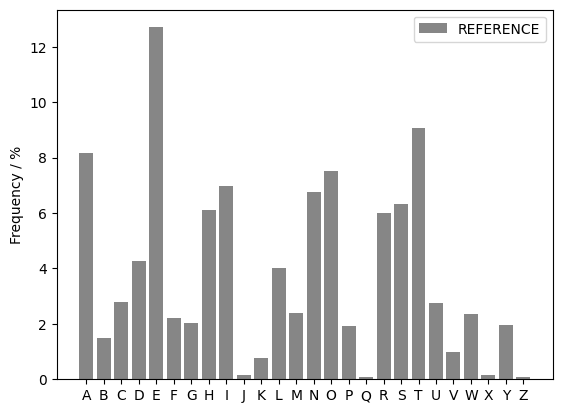

In [35]:
# plot letters frequencies
import matplotlib.pyplot as plt

ascii_uppercase = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'

x = range(len(freq_ref))

plt.bar(x, freq_ref,  color='gray', alpha=0.95, label="REFERENCE")

plt.legend()
plt.xticks(x, ascii_uppercase)
plt.ylabel("Frequency / %")

plt.show()

In [36]:
# read encoded text
with open('the_secret.txt', 'r') as f:
    text = f.read().strip()
# convert to upper case
text = text.upper()
# filter for letters
text = "".join([i for i in text if i in ascii_uppercase])

text

'VJGDQQMDGIKPUYKVJEKVAEQWPEKNYQTMOGPCTTKXKPICVCTVJWTFGPVUJQWUGVJGAYKUJVQFGOQNKUJJKUJQWUGKPQTFGTVQDWKNFCDARCUUCTVJWTUDGUVHTKGPFHQTFRTGHGEVCTTKXGUYCTPKPIJKOQHVJGGPFQHVJGYQTNFHQTFKUTGXGCNGFVQDGCPCNKGPYJQJCFEQOGVQGCTVJVQTGUGCTEJKVHQTVJGVKVWNCTJKVEJJKMGTUIWKFGVQVJGICNCZACPGPQTOQWUYQTMRTQXKFKPIKPHQTOCVKQPCDQWVGXGTARNCPGVCPFRNCEGKPVJGWPKXGTUGVJGVYQJGCFVQCRWDYJGTGVJGNQECNUSWGUVKQPHQTFUMPQYNGFIGQHVJGCRQECNARUGCPCNKGPTCEGMPQYPCUXQIQPUUJQYWRVQFGOQNKUJGCTVJKPQTFGTVQDWKNFCDARCUUHQTCPKPVGTICNCEVKEJKIJYCACTVJWTCPFHQTFOCPCIGVQIGVQPVQVJGXQIQPUJKRLWUVDGHQTGGCTVJKUFGOQNKUJGFYJGTGVJGACTGHQTEGFVQNKUVGPVQJQTTKDNGXQIQPRQGVTACUCHQTOQHVQTVWTGCTVJWTCPFHQTFCTGQTFGTGFVQUCAJQYOWEJVJGANKMGVJGRQGVTAKPQTFGTVQCXQKFDGKPIVJTQYPQWVQHVJGCKTNQEMCPFYJKNGHQTFHKPFUNKUVGPKPIVQDGRCKPHWNCTVJWTDGNKGXGUKVVQDGIGPWKPGNAIQQFUKPEGJWOCPRQGVTAKUCRRCTGPVNAGXGPYQTUGCTVJWTCPFHQTFCTGVJGPRNCEGFKPVQVJGCKTNQEMCPFLGVVKUQPGFKPVQURCEGQPNAVQDGTGUEWGFDABCRJQFDGGDNGDTQZUUJKRVJGJGCTVQHIQNFBCRJQFCUGOKEQWUKPQHHQTFKUVJGRTGUKFGPVQHVJGICNCZACPFKUCEEQORCPK

In [37]:
freq_text = list()
for letter in text:
    print(letter, end=' ')
    freq_text = [0] * 26
    for letter in text:
        print(letter, end=' ')
        freq_text[ascii_uppercase.index(letter)] += 1

V V J G D Q Q M D G I K P U Y K V J E K V A E Q W P E K N Y Q T M O G P C T T K X K P I C V C T V J W T F G P V U J Q W U G V J G A Y K U J V Q F G O Q N K U J J K U J Q W U G K P Q T F G T V Q D W K N F C D A R C U U C T V J W T U D G U V H T K G P F H Q T F R T G H G E V C T T K X G U Y C T P K P I J K O Q H V J G G P F Q H V J G Y Q T N F H Q T F K U T G X G C N G F V Q D G C P C N K G P Y J Q J C F E Q O G V Q G C T V J V Q T G U G C T E J K V H Q T V J G V K V W N C T J K V E J J K M G T U I W K F G V Q V J G I C N C Z A C P G P Q T O Q W U Y Q T M R T Q X K F K P I K P H Q T O C V K Q P C D Q W V G X G T A R N C P G V C P F R N C E G K P V J G W P K X G T U G V J G V Y Q J G C F V Q C R W D Y J G T G V J G N Q E C N U S W G U V K Q P H Q T F U M P Q Y N G F I G Q H V J G C R Q E C N A R U G C P C N K G P T C E G M P Q Y P C U X Q I Q P U U J Q Y W R V Q F G O Q N K U J G C T V J K P Q T F G T V Q D W K N F C D A R C U U H Q T C P K P V G T I C N C E V K E J K I J Y C A C T V J W 

#### plot histogram with letters frequencies

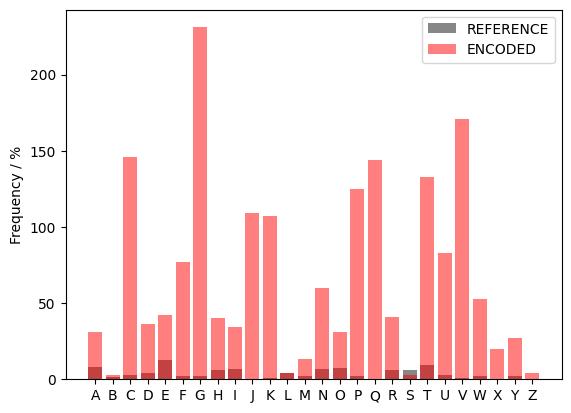

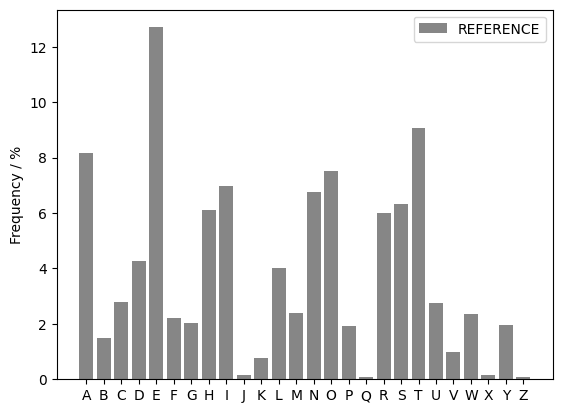

In [40]:
# plot letters frequencies
import matplotlib.pyplot as plt

# plot reference frequency
plt.bar(x, freq_ref,  color='gray', alpha=0.95, label="REFERENCE")
# plot text frequency
plt.bar(x, freq_text, color='r', alpha=0.5, label="ENCODED")

plt.legend()
plt.xticks(x, ascii_uppercase)
plt.ylabel("Frequency / %")

plt.show()


ascii_uppercase = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'

x = range(len(freq_ref))

plt.bar(x, freq_ref,  color='gray', alpha=0.95, label="REFERENCE")

plt.legend()
plt.xticks(x, ascii_uppercase)
plt.ylabel("Frequency / %")

plt.show()

In [39]:
text_decoded = decode(text, 2)
print(text_decoded)

THEBOOKBEGINSWITHCITYCOUNCILWORKMENARRIVINGATARTHURDENTSHOUSETHEYWISHTODEMOLISHHISHOUSEINORDERTOBUILDABYPASSARTHURSBESTFRIENDFORDPREFECTARRIVESWARNINGHIMOFTHEENDOFTHEWORLDFORDISREVEALEDTOBEANALIENWHOHADCOMETOEARTHTORESEARCHITFORTHETITULARHITCHHIKERSGUIDETOTHEGALAXYANENORMOUSWORKPROVIDINGINFORMATIONABOUTEVERYPLANETANDPLACEINTHEUNIVERSETHETWOHEADTOAPUBWHERETHELOCALSQUESTIONFORDSKNOWLEDGEOFTHEAPOCALYPSEANALIENRACEKNOWNASVOGONSSHOWUPTODEMOLISHEARTHINORDERTOBUILDABYPASSFORANINTERGALACTICHIGHWAYARTHURANDFORDMANAGETOGETONTOTHEVOGONSHIPJUSTBEFOREEARTHISDEMOLISHEDWHERETHEYAREFORCEDTOLISTENTOHORRIBLEVOGONPOETRYASAFORMOFTORTUREARTHURANDFORDAREORDEREDTOSAYHOWMUCHTHEYLIKETHEPOETRYINORDERTOAVOIDBEINGTHROWNOUTOFTHEAIRLOCKANDWHILEFORDFINDSLISTENINGTOBEPAINFULARTHURBELIEVESITTOBEGENUINELYGOODSINCEHUMANPOETRYISAPPARENTLYEVENWORSEARTHURANDFORDARETHENPLACEDINTOTHEAIRLOCKANDJETTISONEDINTOSPACEONLYTOBERESCUEDBYZAPHODBEEBLEBROXSSHIPTHEHEARTOFGOLDZAPHODASEMICOUSINOFFORDISTHEPRESIDENTOFTHEGALAXYANDISACCOMPANIE